<a href="https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent

Andrew Ng, from https://www.youtube.com/watch?v=PPLop4L2eGk&list=PLLssT5z_DsK-h9vYZkQkYNWcItqhlRJLN:

* $h_{\theta}(x) = \theta_0 + \theta_1x$
* where $\theta_0$ and $\theta_1$ are parameters
* and h is the hypothesis

## Machine Learning and the Matrix

* Machine learning uses matrices
* To find the parameters of our equation we can use **np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)**
* Where X has a bias (OLS requires manual addition of bias or constant)
* Regression uses several analytical methods such as $y=\alpha + \beta{X} + e$
* and $\beta = \frac{\sum{(x - \bar{x})(y - \bar{y})}}{\sum(x - \bar{x})^2}$
* where $\alpha = \bar{y} - \beta \bar{X}$
* This can overwhelm a machine computing abilities if X is too large
* So we use gradient descent to incrementally find our parameters ($\theta s$)
* https://shashank-ojha.github.io/ParallelGradientDescent/

## Gradient

An increase or decrease in the magnitude of a property (e.g. temperature, pressure, or concentration) observed in passing from one point or moment to another.

## Minimizing the Cost Function

* Here is our challenge: $min J(\theta_0, \theta_1)$ where $J(\theta_0, \theta_1)$ is our cost function
* Start with some $\theta_0, \theta_1$
* Keep changing $\theta_0, \theta_1$ to reduce $J(\theta_0, \theta_1)$ until we hopefully end up with a minimum (Andrew Ng)
* Since this is an incremental learning process we call these increments the learning rate, or $\alpha$

## Gradient Descent Algorithm and the Derivative

* When we have a function such as $f(x) = x^2$ we can find the slope, at any point, of this function by getting the derivative
* We find the derivative of a function using the Power Rule
* The derivative of $f(x) = x^2$ is $f'(x) = 2x$

## Partial Derivative

In mathematics, a partial derivative of a function of several variables is its derivative with respect to one of those variables, with the others held constant (as opposed to the total derivative, in which all variables are allowed to vary). Partial derivatives are used in vector calculus and differential geometry.

https://en.wikipedia.org/wiki/Partial_derivative

* We find the derivative of a function using the Power Rule
* The derivative of $f(x) = x^2$ is $f'(x) = 2x$
* The partial derivative of $f(x, y) = x^2 + y^3$ is $f'(x) = 2x + 0 = 2x$
* In this case we find the partial derivative with respect to x and hold y as a constant
* The derivative of a constant is 0

https://www.mathsisfun.com/calculus/derivatives-partial.html

## Our Final Formula

* $\theta_j := \theta_j - \alpha\frac{\partial}{\partial \theta} J(\theta_0, \theta_1)$
* where := is an assignment operator vs equality operator
* and $\theta_0, \theta_1$ is updated simultaneously
* and $\alpha$ is the learning rate
* and the $\partial$ is the partial derivative
* We repeat $\theta_j := \theta_j - \alpha\frac{\partial}{\partial \theta} J(\theta_0, \theta_1)$ until convergence
* Convergence is a sequence of numbers that approach a limit

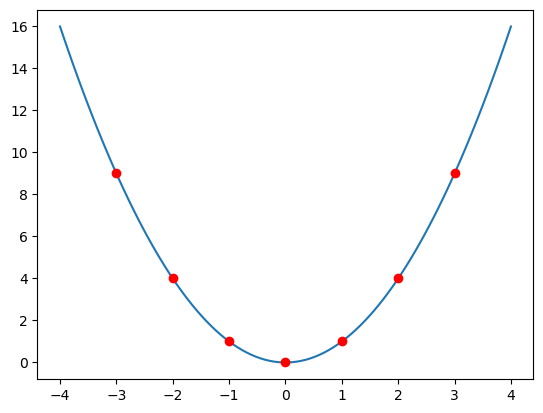

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# define x data range
x = np.linspace(-4, 4, 100)
y = [i**2 for i in x]
plt.plot(x, y)

for i in [-3, -2, -1, 0, 1, 2, 3]:
    plt.plot(i, i**2, 'ro')


* Our function is $y = x^2$
* Our derivative is $\frac{dy}{dx} = 2x$, a new function that defines our slope
* Negative numbers vs Positive numbers trying to get to the minimum

#### MSE

* MSE = $\frac{1}{n}\sum(y - \hat{y})^2$

#### Minimize $J(\theta_0, \theta_1)$

* $\frac{1}{2m}\sum(h_\theta(x) - y)^2$
* $\frac{\partial}{\partial\theta_0} * \frac{1}{m}\sum(h_\theta(x) - y)$
* $\frac{\partial}{\partial\theta_1} * \frac{1}{m}\sum(h_\theta(x) - y)x$
* given $h_{\theta}(x) = \theta_0 + \theta_1x$

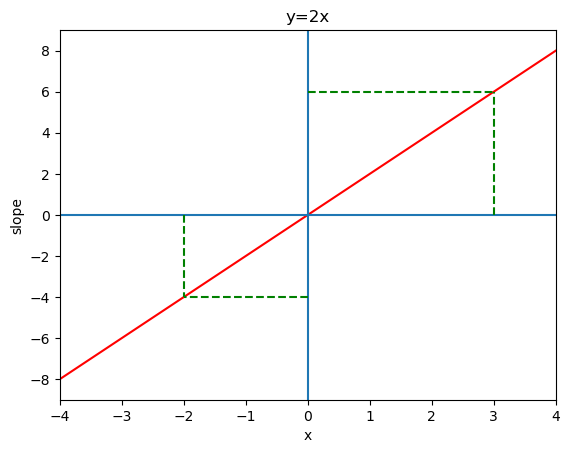

In [ ]:
# our slope, y = 2x
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 100)
y = 2*x
plt.plot(x, y, '-r')
plt.axhline(0)
plt.axvline(0)
plt.hlines(y=-4, xmin=0, xmax=-2, color='g', ls='dashed')
plt.vlines(x=-2, ymin=0, ymax=-4, color='g', ls='dashed')
plt.hlines(y=6, xmin=0, xmax=3, color='g', ls='dashed')
plt.vlines(x=3, ymin=0, ymax=6, color='g', ls='dashed')
plt.title('y=2x')
plt.xlabel('x')
plt.ylabel('slope')
plt.xlim(-4, 4)
plt.ylim(-9, 9)
plt.show()

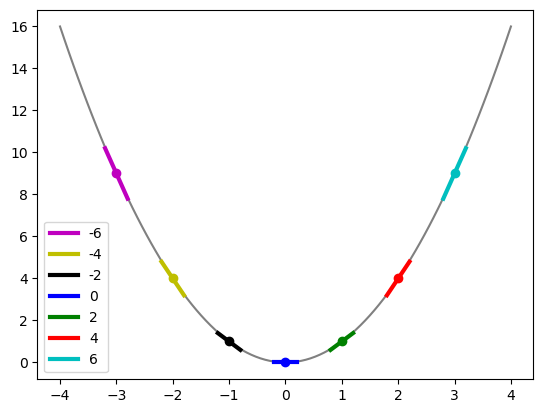

In [ ]:
# https://stackoverflow.com/questions/54961306/how-to-plot-the-slope-tangent-line-of-parabola-at-any-point
import numpy as np
import matplotlib.pyplot as plt

def slope(x):
    return 2*x

def point_slope(x, x1, y1): # y = m(x1) * (x-x1) + y1 vs y - y1 = m(x - x1) where m is slope
    return slope(x1)*(x-x1)+y1 # y = mx + b

# A tangent line to the function f(x) at the point x=a is a line that just touches the graph of the function
# at the point in question and is “parallel” (in some way) to the graph at that point.
# https://tutorial.math.lamar.edu/classes/calci/tangents_rates.aspx

# x data
x = np.linspace(-4, 4, 100)

# colors
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

# plot the parabola with slopes
plt.plot(x, x**2, color='gray')
for i in [-3, -2, -1, 0, 1, 2, 3]:
    line = np.linspace(i-0.2, i+0.2, 10)
    plt.plot(i, i**2, color=colors[i], marker='o', linewidth=10)
    plt.plot(line, point_slope(line, i, i**2), color=colors[i], linewidth=3, label=slope(i))

plt.legend();

### Problems with the Gradient and Momentum

* https://srdas.github.io/DLBook/GradientDescentTechniques.html


Iteration 0: y = -0.21 + 3.98x and the cost: 1053.52
Iteration 10: y = -0.14 + 29.48x and the cost: 391.96
Iteration 20: y = 1.01 + 40.29x and the cost: 271.87
Iteration 30: y = 1.88 + 44.92x and the cost: 249.30
Iteration 110: y = 2.91 + 48.48x and the cost: 243.92
(By Formula: y = 2.91 + 48.48x and the cost: 243.92)


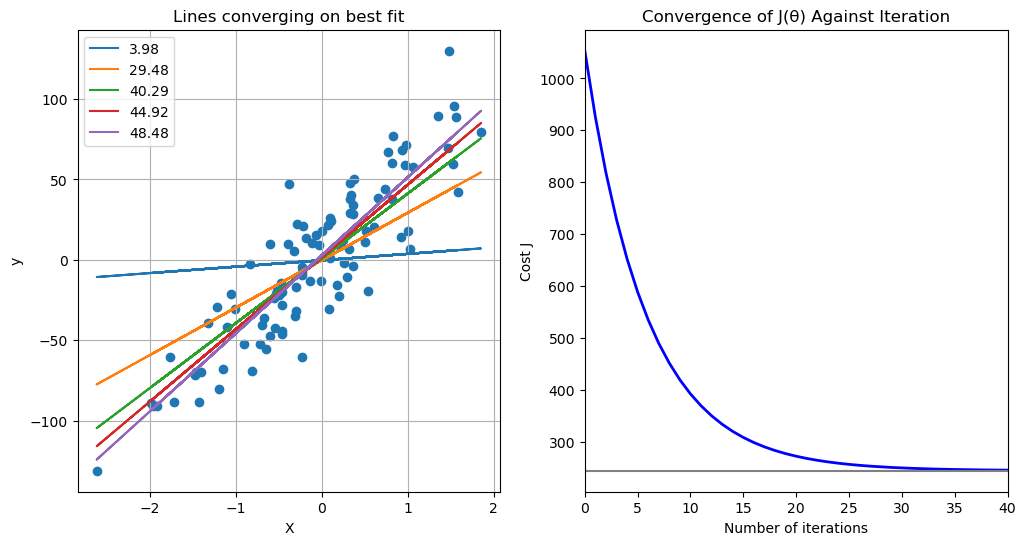

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

def cost_function(X, y, theta):
    # (Sum(h(x) - y)**2 / 2m)
    return ((X.dot(theta) - np.vstack(y.T)) ** 2).sum()/(2 * y.size)

def gradientDescent(X, y, theta, alpha, num_iters):
    # initialize values
    thetas = []
    J_history = np.zeros((num_iters, 1))
    j = 0

    for i in range(num_iters):
        # theta was initialized as [[0], [0]] (simultaneous computation)
        theta = theta - alpha*(1.0/X.shape[0]) * X.T.dot(X.dot(theta) - np.vstack(y.T))
        thetas.append(theta) # store thetas
        J_history[i] = cost_function(X, y, theta) # store cost (mse)

    return theta, thetas, J_history

# create X y dataset
X, y, coef = make_regression(n_samples = 100,
                             n_features = 1,
                             n_targets = 1,
                             noise = 25,
                             coef = True,
                             random_state = 42)

plt.figure(figsize=(12,6))
plt.subplot(121)

# scatterplot
plt.scatter(X, y)

# choose a learning rate
alpha = 0.1
num_iters = 1000

# reshape X and add bias
J = np.append(arr = np.ones((y.size, 1)).astype(int), values = X.reshape(y.size, 1), axis = 1)

# init weights and run gradient descent
theta=[[0], [0]]
theta, thetas, J_history = gradientDescent(J, y, theta, alpha, num_iters)

# plot converging lines
iteration = [0, 10, 20, 30, 110]
iteration_list = []
for i in iteration:
    iteration_list.append(thetas[i])
    print ('Iteration {}: y = {:0.2f} + {:0.2f}x and the cost: {:0.2f}'.format(i, thetas[i][0][0], thetas[i][1][0], J_history[i][0]))
    plt.plot(X, thetas[i][0] + thetas[i][1] * X, '-', label=thetas[i][1][0].round(2))

# line of best fit formula
b, a = np.polyfit(X.flatten(), y, 1)
print(f'(By Formula: y = {a.round(2)} + {b.round(2)}x and the cost: {cost_function(J, y, theta).round(2)})')
plt.grid(True)
plt.title('Lines converging on best fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend();

# Plot the convergence of J_history
plt.subplot(122)
plt.plot(range(J_history.size), J_history, "-b", linewidth=2)
plt.axhline(cost_function(J, y, theta).round(2), color='gray')
plt.title('Convergence of J(\u03B8) Against Iteration')
plt.xlabel('Number of iterations')
plt.ylabel('Cost J')
plt.xlim((0, 40))
plt.show(block=False)

* Start with some $\theta_0, \theta_1$
* Keep changing $\theta_0, \theta_1$ to reduce $J(\theta_0, \theta_1)$, our cost function, until we hopefully end up with a minimum
* Since this is an incremental learning process we call these increments the learning rate, or $\alpha$
* theta = theta - alpha*(1.0/X.shape[0]) * X.T.dot(X.dot(theta) - np.vstack(y.T))
* We repeat $\theta_j := \theta_j - \alpha\frac{\partial}{\partial \theta} J(\theta_0, \theta_1)$ until convergence

## Calculus

MATH 0-1: CALCULUS FOR DATA SCIENCE & MACHINE LEARNING by The Lazy Programmer

### Limits

* Function must be a 1:1 mapping
* Calculus is about rates of change, or the study of continuous change; derivatives
* $\lim\limits_{x \to \alpha} f(x) = L$; the limit of f of x as it approaches some value $\alpha$ is L
* L is the same as the function value
* https://machinelearningmastery.com/a-gentle-introduction-to-limits-and-continuity/

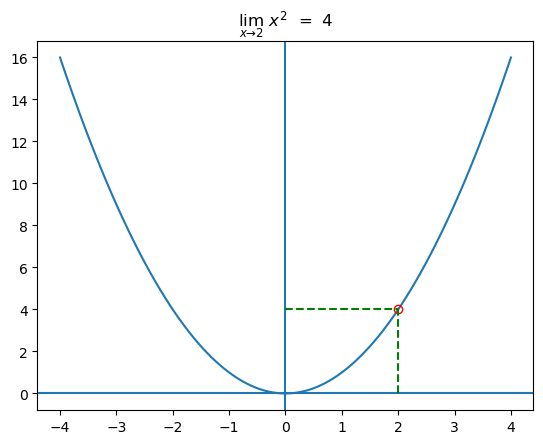

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# define x data range
x = np.linspace(-4, 4, 100)
y = [i**2 for i in x]
plt.plot(x, y)
plt.plot(2, 4, 'ro', markerfacecolor='none', markeredgewidth=1)

plt.axhline(0)
plt.axvline(0)
plt.hlines(y=4, xmin=0, xmax=2, color='g', ls='dashed')
plt.vlines(x=2, ymin=0, ymax=4, color='g', ls='dashed')

plt.title(r'$\lim_{x \to 2} \  x^2 \ = \ 4$')
plt.show()

### Approaching Indeterminacy

* https://www.mathsisfun.com/calculus/limits.html

### Getting Both Sides of $\alpha$

* $\lim\limits_{x \to \alpha^-} f(x) = L^-$
* $\lim\limits_{x \to \alpha^+} f(x) = L^+$

### Asymptote

* A line that continually approaches a given curve but does not meet it at any finite distance
* In analytic geometry, an asymptote of a curve is a line such that the distance between the curve and the line approaches zero as one or both of the x or y coordinates tends to infinity. In projective geometry and related contexts, **an asymptote of a curve is a line which is tangent to the curve at a point at infinity**. https://en.wikipedia.org/wiki/Asymptote
* $ \lim\limits_{x \to \infty} \frac{1}{x} = 0$

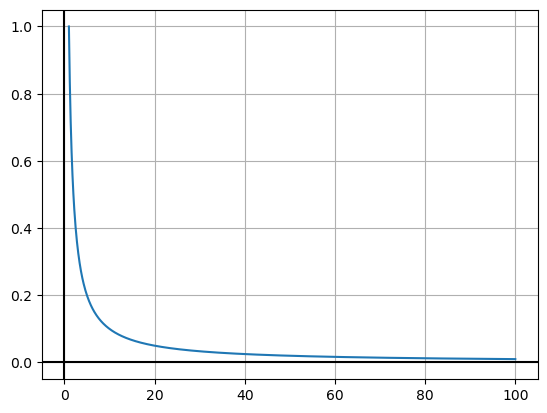

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1, 100, 1000)
y = 1 / x
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.grid()
plt.plot(x, y);

$\lim\limits_{x \to \infty} x^2 = \infty$

### Indeterminate Forms

* In calculus and other branches of mathematical analysis, limits involving an algebraic combination of functions in an independent variable may often be evaluated by replacing these functions by their limits; if the expression obtained after this substitution does not provide sufficient information to determine the original limit, then the expression is called an indeterminate form. htts://en.wikipedia.org/wiki/Indeterminate_form
* $\lim\limits_{x \to 1} \frac{x^2 - 1}{x - 1} = 2$
* But, when x = 1 we have 0 / 0
* The closer we get to 1 the closer we get to 2

In [ ]:
x = .9999
print((x**2 - 1) / (x - 1))

1.9998999999994975


## Derivatives

### Slopes, Tangent Lines, and Derivatives

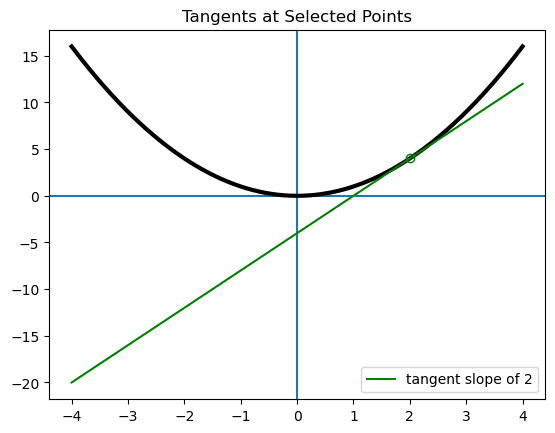

In [ ]:
from scipy import interpolate
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-4, 4, 1000)
y = x**2
tck = interpolate.splrep(x, y)

x0 = 2
y0 = interpolate.splev(x0, tck)
dydx0 = interpolate.splev(x0, tck, der=1)
tngnt0 = lambda x: dydx0*x + (y0-dydx0*x0)

plt.axhline(0)
plt.axvline(0)
plt.plot(x, y, linewidth=3, color='black')
plt.plot(x0, y0, marker='o', color='green', markerfacecolor='none', markeredgewidth=1)
plt.plot(x, tngnt0(x), 'g-', label='tangent slope of 2')

plt.legend()
plt.title(f'Tangents at Selected Points')
plt.show()

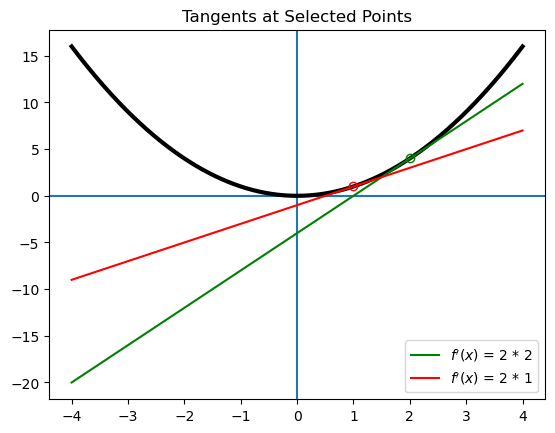

In [ ]:
from scipy import interpolate
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-4, 4, 1000)
y = x**2
tck = interpolate.splrep(x, y)

x0 = 2
y0 = interpolate.splev(x0, tck)
dydx0 = interpolate.splev(x0, tck, der=1)
tngnt0 = lambda x: dydx0*x + (y0-dydx0*x0)

x1 = 1
y1 = interpolate.splev(x1, tck)
dydx1 = interpolate.splev(x1, tck, der=1)
tngnt1 = lambda x: dydx1*x + (y1-dydx1*x1)

plt.axhline(0)
plt.axvline(0)
plt.plot(x, y, linewidth=3, color='black')
plt.plot(x0, y0, marker='o', color='green', markerfacecolor='none', markeredgewidth=1)
plt.plot(x, tngnt0(x), 'g-', label=r'$f^\prime(x)$ = 2 * 2')

plt.plot(x1, y1, marker='o', color='red', markerfacecolor='none', markeredgewidth=1)
plt.plot(x, tngnt1(x), 'r-', label=r'$f^\prime(x)$ = 2 * 1')

plt.legend()
plt.title(f'Tangents at Selected Points')
plt.show()

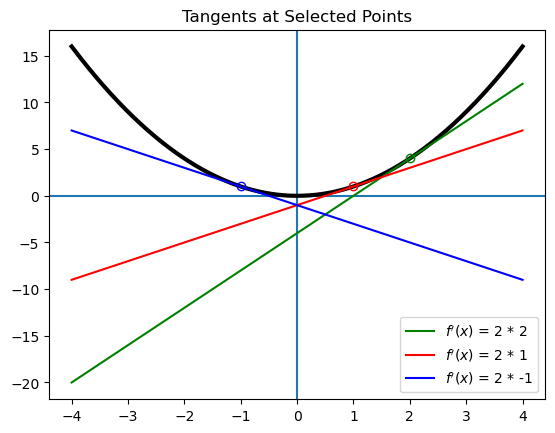

In [ ]:
from scipy import interpolate
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-4, 4, 1000)
y = x**2
tck = interpolate.splrep(x, y)

x0 = 2
y0 = interpolate.splev(x0, tck)
dydx0 = interpolate.splev(x0, tck, der=1)
tngnt0 = lambda x: dydx0*x + (y0-dydx0*x0)

x1 = 1
y1 = interpolate.splev(x1, tck)
dydx1 = interpolate.splev(x1, tck, der=1)
tngnt1 = lambda x: dydx1*x + (y1-dydx1*x1)

xn1 = -1
yn1 = interpolate.splev(xn1, tck)
dydxn1 = interpolate.splev(xn1, tck, der=1)
tngntn1 = lambda x: dydxn1*x + (yn1-dydxn1*xn1)

plt.axhline(0)
plt.axvline(0)
plt.plot(x, y, linewidth=3, color='black')
plt.plot(x0, y0, marker='o', color='green', markerfacecolor='none', markeredgewidth=1)
plt.plot(x, tngnt0(x), 'g-', label=r'$f^\prime(x)$ = 2 * 2')

plt.plot(x1, y1, marker='o', color='red', markerfacecolor='none', markeredgewidth=1)
plt.plot(x, tngnt1(x), 'r-', label=r'$f^\prime(x)$ = 2 * 1')

plt.plot(xn1, yn1, marker='o', color='blue', markerfacecolor='none', markeredgewidth=1)
plt.plot(x, tngntn1(x), 'b-', label=r'$f^\prime(x)$ = 2 * -1')

plt.legend()
plt.title(f'Tangents at Selected Points')
plt.show()

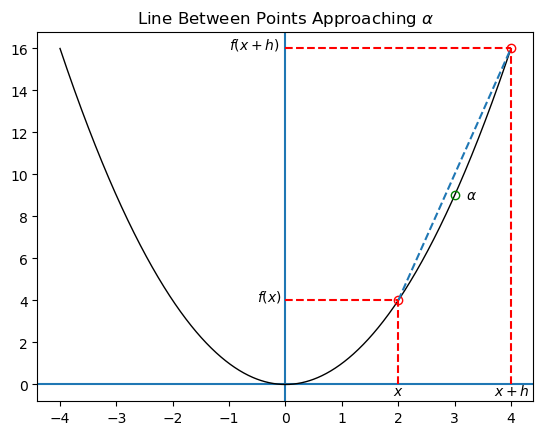

In [ ]:
from scipy import interpolate
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-4, 4, 1000)
y = x**2
tck = interpolate.splrep(x, y)

x0 = 4
y0 = interpolate.splev(x0, tck)
dydx0 = interpolate.splev(x0, tck, der=1)
tngnt0 = lambda x: dydx0*x + (y0-dydx0*x0)

x1 = 2
y1 = interpolate.splev(x1, tck)
dydx1 = interpolate.splev(x1, tck, der=1)
tngnt1 = lambda x: dydx1*x + (y1-dydx1*x1)

plt.axhline(0)
plt.axvline(0)
plt.plot(x, y, linewidth=1, color='black')
plt.plot(x0, y0, marker='o', color='red', markerfacecolor='none', markeredgewidth=1)
plt.plot(x1, y1, marker='o', color='red', markerfacecolor='none', markeredgewidth=1)
plt.plot(3, 9, marker='o', color='green', markerfacecolor='none', markeredgewidth=1)
plt.text(3.2, 8.8, r'$\alpha$')

point1 = [2, 4]
point2 = [4, 16]
x_values = [point1[0], point2[0]]
y_values = [point1[1], point2[1]]
plt.plot(x_values, y_values, linestyle = '--')

plt.hlines(y=4, xmin=0, xmax=2, color='r', ls='dashed')
plt.vlines(x=2, ymin=0, ymax=4, color='r', ls='dashed')
plt.hlines(y=16, xmin=0, xmax=4, color='r', ls='dashed')
plt.vlines(x=4, ymin=0, ymax=16, color='r', ls='dashed')

plt.text(1.9, -0.5, r'$x$')
plt.text(3.7, -0.5, r'$x + h$')

plt.text(-0.5, 4, r'$f(x)$')
plt.text(-1, 16, r'$f(x + h)$')


plt.title(r'Line Between Points Approaching $\alpha$')
plt.show()

* m = rise/run
* $\frac{\Delta(y)}{\Delta(x)}$
* $\frac{y_2 - y_1}{x_2 - x_1}$
* Intuitively, to find the tangent at $\alpha$ we just move our two points closer and closer

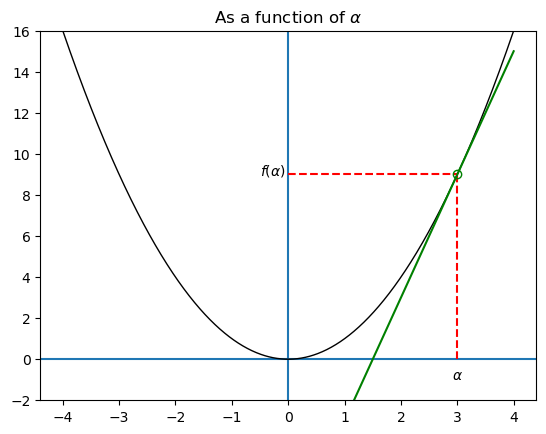

In [ ]:
from scipy import interpolate
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-4, 4, 1000)
y = x**2
tck = interpolate.splrep(x, y)

x0 = 3
y0 = interpolate.splev(x0, tck)
dydx0 = interpolate.splev(x0, tck, der=1)
tngnt0 = lambda x: dydx0*x + (y0-dydx0*x0)

plt.axhline(0)
plt.axvline(0)

plt.plot(x, y, linewidth=1, color='black')
plt.hlines(y=9, xmin=0, xmax=3, color='r', ls='dashed')
plt.vlines(x=3, ymin=0, ymax=9, color='r', ls='dashed')

plt.plot(x0, y0, marker='o', color='green', markerfacecolor='none', markeredgewidth=1)
plt.plot(x, tngnt0(x), 'g-', label='tangent of 2')

plt.text(-0.5, 9, r'$f(\alpha)$')
plt.text(2.9, -1, r'$\alpha$')

plt.ylim(-2, 16)

plt.title(r'As a function of $\alpha$')
plt.show()

### Slope of Tangent Line

$m = \lim\limits_{x \to \alpha} \frac{f(x) - f(a)}{x - a}$

### Alternative Equation

$m = \lim\limits_{h \to 0} \frac{f(a + h) - f(h)}{h}$

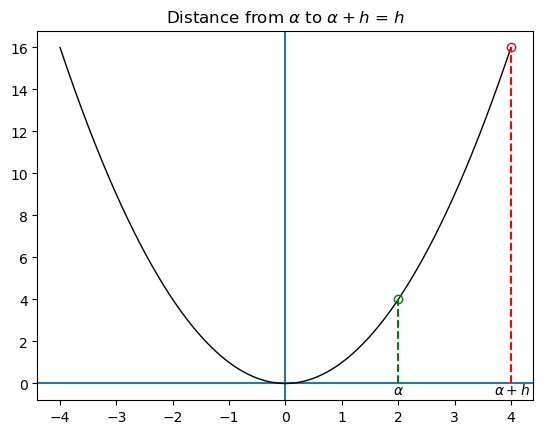

In [ ]:
from scipy import interpolate
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-4, 4, 1000)
y = x**2

plt.axhline(0)
plt.axvline(0)
plt.plot(x, y, linewidth=1, color='black')
plt.plot(2, 4, marker='o', color='green', markerfacecolor='none', markeredgewidth=1)
plt.plot(4, 16, marker='o', color='red', markerfacecolor='none', markeredgewidth=1)

plt.vlines(x=2, ymin=0, ymax=4, color='g', ls='dashed')
plt.vlines(x=4, ymin=0, ymax=16, color='r', ls='dashed')

plt.text(1.9, -0.5, r'$\alpha$')
plt.text(3.7, -0.5, r'$\alpha + h$')

plt.title(r'Distance from $\alpha$ to $\alpha + h$ = $h$')
plt.show()

* $m = \lim\limits_{h \to 0} \frac{f(a + h) - f(h)}{h}$
* a + h - a = h

### The Derivative

* The derivative is the slope
* The derivative of a function f at $\alpha$ is $f'(\alpha) = \lim\limits_{h \to 0} \frac{f(a + h) - f(h)}{h}$
* You may see $f'(\alpha) = \lim\limits_{h \to \alpha} \frac{f(x) - f(a)}{x - a}$
* Expressed as a function: $f'(x) = \lim\limits_{h \to 0} \frac{f(x + h) - f(x)}{h}$
* If f is differentiable at $\alpha$, then f is continuous at $\alpha$
* Differentiable means we can get a derivative (not everything is differentiable)
* $\Delta{x} \to dx$ is the infinitesimal distance
* dx is the infinitesimal change in x. Delta x means a bigger change in x, in the sense the change in x over an interval. It is the difference between two values of x. https://www.quora.com/What-is-the-difference-between-dx-and-Delta-x

### The Quadratic

$f(x) = x^2$, find $f'(x)$

* $f'(x) = \lim\limits_{h \to 0} \frac{f(x + h) - f(x)}{h}$
* $= \lim\limits_{h \to 0} \frac{(x + h)^2 - x^2}{h}$
* $= \lim\limits_{h \to 0} \frac{x^2 + 2xh + h^2 - x^2}{h}$
* $= \lim\limits_{h \to 0} \frac{2xh + h^2}{h}$
* $= \lim\limits_{h \to 0} 2x + h$
* $= \lim\limits_{h \to 0} 2x$
* $\frac{d}{dx}(x^2) = 2x$
* If $y=x^2$ then $\frac{dy}{dx} = 2x$

### The Power Rule

* We find the derivative of a function using the Power Rule
* The derivative of $f(x) = x^2$ is $f'(x) = 2x$
* The partial derivative of $f(x, y) = x^2 + y^3$ is $f'(x) = 2x + 0 = 2x$
* In this case we find the partial derivative with respect to x and hold y as a constant
* The derivative of a constant is 0

https://www.mathsisfun.com/calculus/derivatives-partial.html